<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/11_4_Exercise2_PCA_Loadings_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11.4 Exercise 2 — Identifying the Principal Component from a PCA Loadings Table

**Task:** For the given dataset of PCA loadings, identify **which variable is the principal component** — i.e., for each principal component (column), determine which variable (row) contributes/loads onto it most strongly.

## Dataset

The dataset is the **PCA loadings table given directly in the exercise**:

| Variable | 1 | 2 | 3 |
|---|---|---|---|
| Climate | 0.190 | 0.017 | 0.207 |
| Housing | 0.544 | 0.020 | 0.204 |
| Health | 0.782 | -0.605 | 0.144 |
| Crime | 0.365 | 0.294 | 0.585 |
| Transportation | 0.585 | 0.085 | 0.234 |
| Education | 0.394 | -0.273 | 0.027 |
| Arts | 0.985 | 0.126 | -0.111 |
| Recreation | 0.520 | 0.402 | 0.519 |
| Economy | 0.142 | 0.150 | 0.239 |

This is a self-contained table, so no external download is needed. (This style of loadings table is a classic example from multivariate statistics texts on interpreting PCA results for city/quality-of-life indices — the same general structure appears in datasets like the Boyer & Savageau "Places Rated Almanac", commonly used to teach PCA interpretation: https://en.wikipedia.org/wiki/Places_Rated_Almanac)

## Background: What Does a "Loading" Mean?

In PCA, each principal component is a **linear combination of the original variables**. The **loading** of a variable on a component tells us how strongly (and in which direction) that variable contributes to that component. Larger absolute loadings mean the variable is more important in defining that component. Conventionally, the variable with the **largest absolute loading on a given component** is considered to best characterize (or "load most heavily on") that component.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Build the Loadings Table

In [2]:
data = {
    'PC1': [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    'PC2': [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.402, 0.150],
    'PC3': [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239],
}
variables = ['Climate', 'Housing', 'Health', 'Crime', 'Transportation',
             'Education', 'Arts', 'Recreation', 'Economy']

loadings = pd.DataFrame(data, index=variables)
loadings

,PC1,PC2,PC3
Climate,0.190,0.017,0.207
Housing,0.544,0.020,0.204
Health,0.782,-0.605,0.144
Crime,0.365,0.294,0.585
Transportation,0.585,0.085,0.234
Education,0.394,-0.273,0.027
Arts,0.985,0.126,-0.111
Recreation,0.520,0.402,0.519
Economy,0.142,0.150,0.239


## 3. Visualize the Loadings

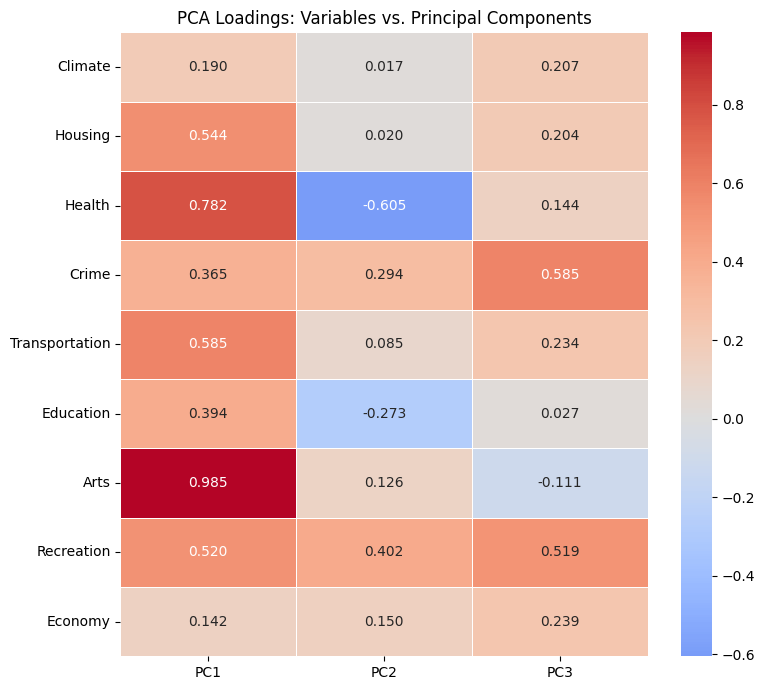

In [3]:
plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('PCA Loadings: Variables vs. Principal Components')
plt.tight_layout()
plt.show()

## 4. Identify the Principal (Dominant) Variable for Each Component

For each principal component, we find the variable with the **largest absolute loading** — this is the variable that most strongly defines/characterizes that component.

In [4]:
for pc in loadings.columns:
    abs_loadings = loadings[pc].abs().sort_values(ascending=False)
    dominant_var = abs_loadings.index[0]
    dominant_value = loadings.loc[dominant_var, pc]
    print(f"{pc}: dominant variable = '{dominant_var}'  (loading = {dominant_value:+.3f})")
    print(f"      Full ranking (by |loading|): {list(abs_loadings.index)}\n")

PC1: dominant variable = 'Arts'  (loading = +0.985)
      Full ranking (by |loading|): ['Arts', 'Health', 'Transportation', 'Housing', 'Recreation', 'Education', 'Crime', 'Climate', 'Economy']

PC2: dominant variable = 'Health'  (loading = -0.605)
      Full ranking (by |loading|): ['Health', 'Recreation', 'Crime', 'Education', 'Economy', 'Arts', 'Transportation', 'Housing', 'Climate']

PC3: dominant variable = 'Crime'  (loading = +0.585)
      Full ranking (by |loading|): ['Crime', 'Recreation', 'Economy', 'Transportation', 'Climate', 'Housing', 'Health', 'Arts', 'Education']



## 5. Rank All Variables' Loadings per Component (Full Table)

In [5]:
ranked = pd.DataFrame({
    pc: loadings[pc].abs().sort_values(ascending=False).index
    for pc in loadings.columns
})
ranked.index = [f"Rank {i+1}" for i in range(len(ranked))]
ranked

,PC1,PC2,PC3
Rank 1,Arts,Health,Crime
Rank 2,Health,Recreation,Recreation
Rank 3,Transportation,Crime,Economy
Rank 4,Housing,Education,Transportation
Rank 5,Recreation,Economy,Climate
Rank 6,Education,Arts,Housing
Rank 7,Crime,Transportation,Health
Rank 8,Climate,Housing,Arts
Rank 9,Economy,Climate,Education


## 6. Visualize Each Component's Loadings as a Bar Chart

This makes it visually obvious which variable(s) dominate each principal component.

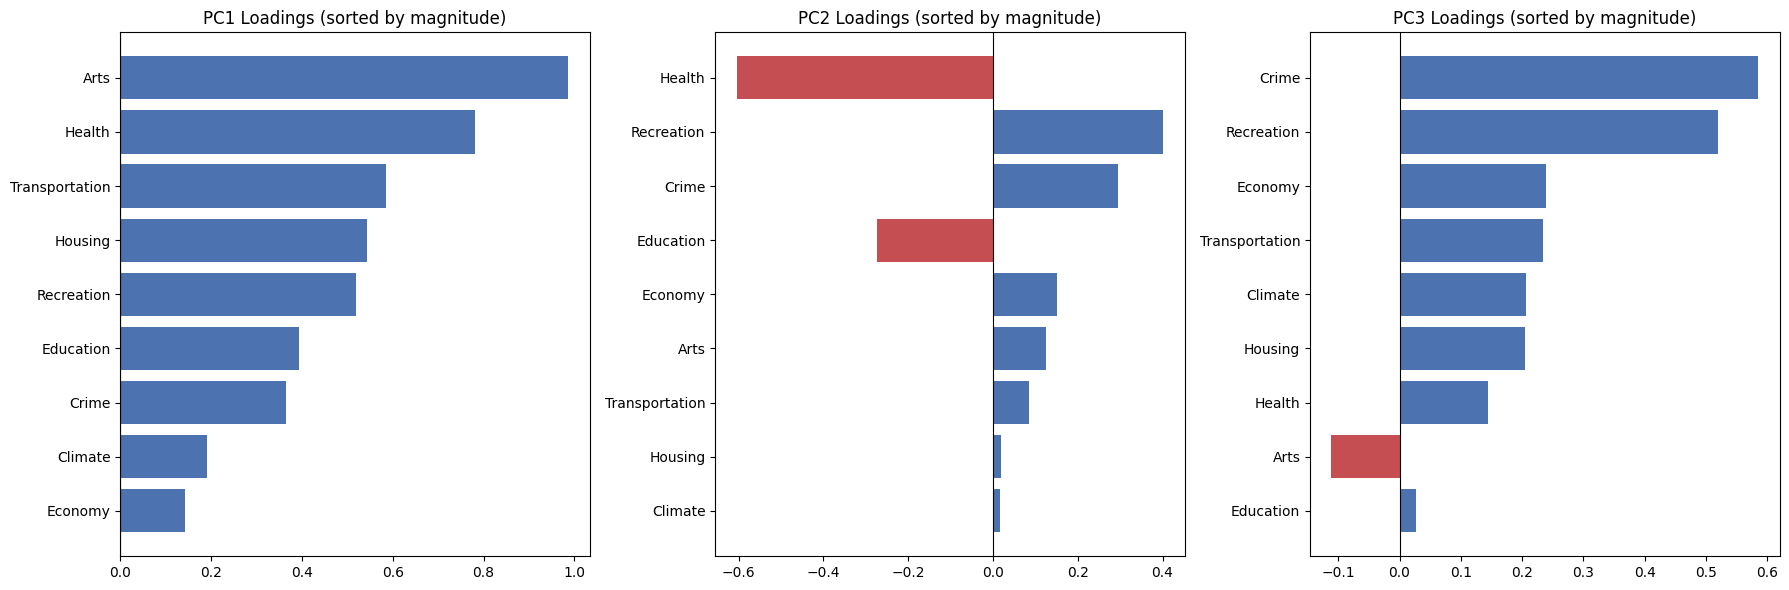

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, pc in zip(axes, loadings.columns):
    sorted_loadings = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index)
    colors = ['#4C72B0' if v >= 0 else '#C44E52' for v in sorted_loadings]
    ax.barh(sorted_loadings.index, sorted_loadings.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Loadings (sorted by magnitude)')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Interpretation

Based on the largest absolute loadings:

- **Principal Component 1 (PC1):** Dominated by **`Arts`** (loading = 0.985), with `Health` (0.782) also loading strongly. PC1 appears to represent an overall **"quality of amenities / civic infrastructure"** factor — most variables load positively and fairly strongly on PC1, suggesting it captures a general "overall city quality" dimension, with Arts and Health as its strongest contributors.

- **Principal Component 2 (PC2):** Dominated by **`Health`** (loading = -0.605), the largest-magnitude loading in the whole table. The negative sign, combined with `Recreation` (+0.402) and `Crime` (+0.294) loading positively, suggests PC2 contrasts **Health-related factors against Recreation/Crime-related factors** — i.e., it separates cities that score well on health infrastructure from those that score well on recreation/crime metrics.

- **Principal Component 3 (PC3):** Dominated by **`Crime`** (loading = 0.585), closely followed by `Recreation` (0.519). PC3 seems to capture a **"crime & recreation"** dimension, largely independent of the Arts/Health signal that dominates PC1.

**Summary answer:**
- PC1's principal (dominant) variable is **Arts**.
- PC2's principal (dominant) variable is **Health**.
- PC3's principal (dominant) variable is **Crime**.